In [1]:
##TODO: Change city name logic to city id logic - half done, but code may be broken

import pandas as pd
import numpy as np
import scipy
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Option 2: Read directly from GitHub and assign to an object

cities = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-05-12/cities.csv')
links = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-05-12/links.csv')

In [2]:
#Now that we have data imported, let's look at what it contains:

print(cities.head())
print(links.head())

print(links[links['source'] == 'Q734532'])
print(links[links['target'] == 'Q734532'])

        id      name         lng        lat country countrycd continent
0  Q734532    Fukaya  139.281500  36.197472   Japan        JP      Asia
1  Q838366  Ishigaki  124.185250  24.344500   Japan        JP      Asia
2  Q747362     Tsuru  138.905444  35.551528   Japan        JP      Asia
3  Q836836      Koga  139.755444  36.178250   Japan        JP      Asia
4  Q823988  Kakegawa  137.998389  34.768750   Japan        JP      Asia
    source   target
0  Q734532  Q873835
1  Q838366  Q242783
2  Q747362  Q271917
3  Q836836  Q385684
4  Q823988  Q386052
    source   target
0  Q734532  Q873835
      source   target
1486  Q49220  Q734532


We'd like to learn more about this data set, particularly in relationship to questions like "Are all these countries related to each other through twin cities"? "Which city is the most connected?" and "Which countries are the most connected?". When looking at city connectedness, we can get that more or less directly through the links dataset. But it may be useful to have a matrix of our countries too.

In [3]:
#Question 1 - Which city is the most connected?
city_list = pd.concat([links['source'], links['target']]).value_counts().reset_index()
cities_analyze = pd.merge(cities, city_list, how='left', left_on = 'id', right_on = 'index')
# print(cities_analyze.head())

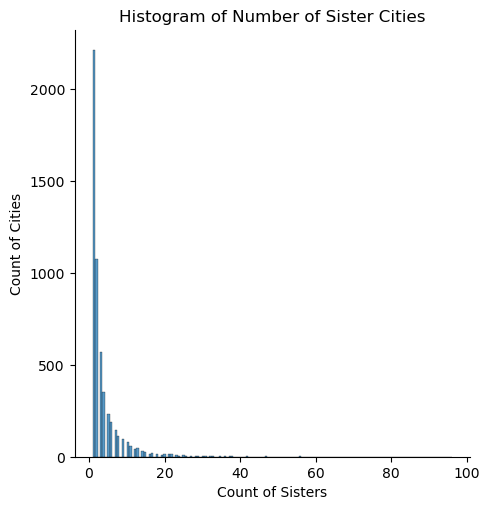

In [87]:
#print(cities.sort_values(['count'], ascending = False).head())
#print(cities.sort_values(['count'], ascending = True).head())

plot = sns.displot(cities_analyze, x="count")
plot.ax.set_xlabel('Count of Sisters')
plot.ax.set_ylabel('Count of Cities')
plot.ax.set_title("Histogram of Number of Sister Cities")
temp = plot.ax.get_figure()
temp.savefig('Documents/TidyTuesday260512/hist_nb_sister_cities.png', dpi=300)

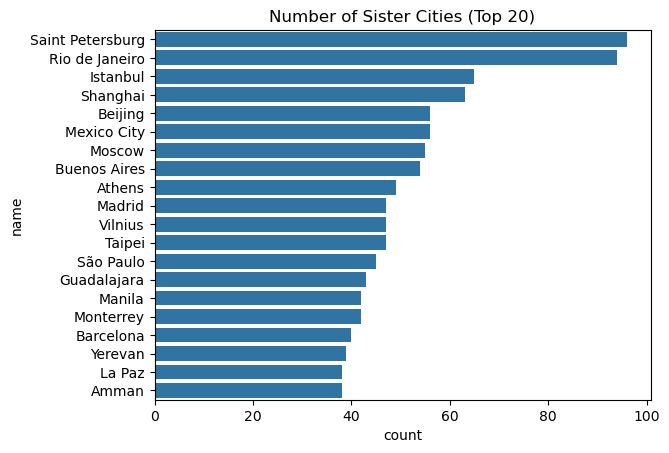

In [92]:
plt = sns.barplot(cities_analyze.sort_values(['count'], ascending = False).head(20), x = 'count' , y='name', orient ='y')
plt.set_title('Number of Sister Cities (Top 20)')
temp = plt.get_figure()
temp.savefig('Documents/TidyTuesday260512/bar_most_sister_cities.png', dpi=300)

Okay! This makes a lot of sense. Most sister cities only have one other connection, and we're seeing a exponential-like distribution for the number of sister cities any one city has. We're also seeing that the cities that have a lot of sister cities are large, international cities. One thing I'm thinking about here is if there are duplicates in this data (for example, is there a row that shows La Paz and Istanbul are sisters, but also a row that shows Istanbul and La Paz as sisters?) That's one piece of data checking I'd like to do - and we can do something like that by making sure the pairs in cities are ordered.

In [6]:
#Data Checking

#Check 1: Data is not ordered by pairs, but we'll assign an order to them
print(len(links))
print(len(links[links['source'] > links['target']]))

links['source_1'] = np.minimum(links['source'],links['target'])
links['source_2'] = np.maximum(links['source'],links['target'])

#Now that we have a well-defined ordering, drop any duplicate rows
links.drop_duplicates(inplace = True)

#No duplicates dropped - maybe a different ordering was used? Either way, good check :)
print(len(links))
                            

10596
5120
10596


In [7]:
#Now, let's get a more detailed linked data set so that we can understand and choose how detailed we want to make our analysis
links_detail = pd.merge(links, cities[['id','name','country','continent']], how='left', left_on = 'source', right_on = 'id')
links_detail = pd.merge(links_detail, cities[['id','name','country','continent']], how='left', left_on = 'target', right_on = 'id', suffixes=['_source','_target'])
print(links_detail.head())

    source   target source_1 source_2 id_source name_source country_source  \
0  Q734532  Q873835  Q734532  Q873835   Q734532      Fukaya          Japan   
1  Q838366  Q242783  Q242783  Q838366   Q838366    Ishigaki          Japan   
2  Q747362  Q271917  Q271917  Q747362   Q747362       Tsuru          Japan   
3  Q836836  Q385684  Q385684  Q836836   Q836836        Koga          Japan   
4  Q823988  Q386052  Q386052  Q823988   Q823988    Kakegawa          Japan   

  continent_source id_target name_target country_target continent_target  
0             Asia   Q873835     Tomioka          Japan             Asia  
1             Asia   Q242783     Okazaki          Japan             Asia  
2             Asia   Q271917     Kushiro          Japan             Asia  
3             Asia   Q385684         Ono          Japan             Asia  
4             Asia   Q386052        Ōshū          Japan             Asia  


In [15]:
#Let's create a random sample of 10 rows for algorithmic testing:
int_index = np.random.randint(0, len(links_detail), size=10)
print(int_index)

[4216 7339 8138 3542 1876 5270 8241 9249  719 1997]


In [14]:
#Let's write an algorithm to cluster cities based on links.
#I like the idea of using set notation to do this, but this might not be optimal for future questions
#I'm also thinking if matrices could be useful, but I'd like to see number of clusters first, and then make decisions on if matrix notation makes sense

#First attempt at a clustering algorithm - this doesn't fully cluster the cities correctly.
def cluster_links(df, col_1 = 'source', col_2 = 'target'):
    cluster_list = [set()]
    for index, row in df.iterrows():
        new_cluster = True
        for cluster in cluster_list:
            if row[col_1] in cluster:
                cluster.add(row[col_2])
                new_cluster = False
            elif row[col_2] in cluster:
                cluster.add(row[col_1])
                new_cluster = False
        if new_cluster:
            cluster_list.append({row[col_1], row[col_2]})        
    return [x for x in cluster_list if x != set()]

# test = cluster_links(links)

# print(len(test))

#I could fix it with a while loop, but I did some research, and want to try to implement a Union Find inspired algorithm
#This is correct, but inefficient due to the way we're traversing sets twice, it's slow until we can get sizable clusters
def union_list(list):
    list_union = set()
    for item in list:
        list_union.union(item)
    return list_union

def union_find(cities, links, cluster_level = 'country', col_1 = 'source', col_2 = 'target'):
    if cluster_level not in ['city','country','continent']:
        raise ValueError('Invalid cluster_level entry.')
    

    if cluster_level == 'city':
        col_1 = 'name_' + col_1
        col_2 = 'name_' + col_2
        clusters = cities['name'].apply(lambda x: {x}).tolist()
    else:
        col_1 = cluster_level + '_' + col_1
        col_2 = cluster_level + '_' + col_2
        clusters = cities[cluster_level].apply(lambda x: {x}).tolist()
       

    for index, row in links.iterrows():
        #Pass through all members of "clusters" once
        union_temp = [x for x in clusters if (row[col_1] in x or row[col_2] in x)]
        union_temp = union_list(union_temp)

        #Pass through all members of "clusters" again
        clusters = [x for x in clusters if (row[col_1] not in x and row[col_2] not in x)]

        clusters.append(union_temp)
    return [x for x in clusters if x != set()]
    
print(len(cities))
# test = union_find(cities, links_detail)

#Attempt 3: We stepped out of set notation until the very end, and we had to do some optimization by adding the counter and figuring how to flatten
#the dictionary to allow recursion to run at the city level without hitting a recursion error. But this is much faster, and passes smell checks.
#Also, Claude checks, although those were not exhaustive.

def find_helper(city, city_dict, counter):
    if city_dict[city] == city:
        return (city, counter)
    else:
        root_city, counter = find_helper(city_dict[city], city_dict, counter + 1)
        city_dict[city] = root_city
        return (root_city, counter)

def union_helper(helper_pair1, helper_pair2, city_dict):
    city_1, counter_1 = helper_pair1
    city_2, counter_2 = helper_pair2
    if counter_1 <= counter_2:
        city_dict[city_2] = city_1
    else:
        city_dict[city_1] = city_2
    return city_dict

def union_find2(cities, links, cluster_level = 'country', col_1 = 'source', col_2 = 'target'):
    if cluster_level not in ['city','country','continent']:
        raise ValueError('Invalid cluster_level entry.')

    if cluster_level == 'city':
        col_1 = 'id_' + col_1
        col_2 = 'id_' + col_2
        clusters = {x: x for x in cities['id']}
    else:
        col_1 = cluster_level + '_' + col_1
        col_2 = cluster_level + '_' + col_2
        clusters = {x: x for x in cities[cluster_level]}

    print('col_1: ' + col_1)
    print('col_2: ' + col_2)

    for index, row in links.iterrows():
        cluster_dict = union_helper(find_helper(row[col_1], clusters, 0), find_helper(row[col_2], clusters, 0), clusters)

    city_set = {}
    for entry in cluster_dict:
        root_city, depth = find_helper(entry, clusters, 0)
        if root_city not in city_set:
            city_set[root_city] = {entry}
        else:
            city_set[root_city].add(entry)
    
    return (cluster_dict, city_set)

cluster_dict, city_sets = union_find2(cities, links_detail, cluster_level = 'city')

print(len(city_sets))
# print(next(iter(city_sets.items())))
    

5470
col_1: id_source
col_2: id_target
364


Great! We finally found a quick way to get clusters of continents, countries, and cities. It appears that all countries are connected by sister cities, which is cool. We also found that there are 364 clusters of cities, which surprised me - this is a pretty significant clustering at the city level, especially since I was expecting with so many single-connection cities that a bunch of small towns would be paired off. But let's dig further into this - how big is each set? How many 2-sets? How big is the St. Petersburg set?

In [17]:
#Let's put the clusters into a data frame. I think it'll make things easier
city_df = pd.DataFrame(
    [(i, k, city) for i, (k, v) in enumerate(city_sets.items()) for city in v],
    columns=['cluster', 'original_key', 'id']
)

print(city_df.groupby('cluster')['id'].nunique().sort_values(ascending = False))

city_df = pd.merge(city_df, cities[['id','name']], how='left', left_on = 'id',right_on = 'id')

print(city_df[city_df['name']=='Saint Petersburg'])

print(city_df[city_df['cluster']==79])

cluster
0      4553
79       16
73       10
164       7
93        6
       ... 
353       2
352       2
335       2
6         2
5         2
Name: id, Length: 364, dtype: int64
     cluster original_key    id              name
823        0       Q27469  Q656  Saint Petersburg
      cluster original_key        id              name
4760       79     Q1002944   Q648071  Mińsk Mazowiecki
4761       79     Q1002944  Q1789604             Krnov
4762       79     Q1002944   Q498575          Northeim
4763       79     Q1002944   Q570057            Karben
4764       79     Q1002944   Q890949           Bohumín
4765       79     Q1002944   Q574170      Ludwigsfelde
4766       79     Q1002944  Q1002944      Zdzieszowice
4767       79     Q1002944   Q501865            Bassum
4768       79     Q1002944   Q986984           Prudnik
4769       79     Q1002944     Q2707            Beckum
4770       79     Q1002944   Q970086             Lacey
4771       79     Q1002944  Q2338831             Pefki
4772     

0
    source   target source_1 source_2  cluster_source  lng_source  lat_source  \
0  Q734532  Q873835  Q734532  Q873835               0  139.281500   36.197472   
1  Q838366  Q242783  Q242783  Q838366               0  124.185250   24.344500   
2  Q747362  Q271917  Q271917  Q747362               0  138.905444   35.551528   
3  Q836836  Q385684  Q385684  Q836836               1  139.755444   36.178250   
4  Q823988  Q386052  Q386052  Q823988               0  137.998389   34.768750   

   lng_target  lat_target  
0  138.889917   36.259917  
1  137.173028   34.954722  
2  144.381722   42.984889  
3  136.487500   35.979722  
4  141.139139   39.144472  


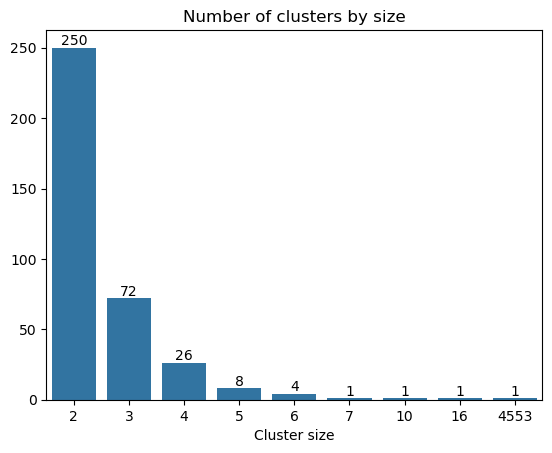

In [90]:
#Cool. Now let's work on visualizing. Let's set up our data first
value_counts = city_df.groupby('cluster')['id'].nunique().value_counts().sort_index()
plot = sns.barplot(x=value_counts.index, y=value_counts.values)
plot.bar_label(plot.containers[0])
plot.set_title('Number of clusters by size')
plot.set_xlabel('Cluster size')

city_df_detail = pd.merge(city_df[['cluster','id']], cities[['lng','lat','name','id']], how = 'left', left_on = 'id', right_on = 'id')
city_df_viz = pd.merge(links, city_df_detail, how = 'left', left_on = 'source', right_on='id')
city_df_viz = pd.merge(city_df_viz, city_df_detail, how = 'left', left_on = 'target', right_on ='id', suffixes = ('_source','_target'))

print(sum(city_df_viz['cluster_source'] != city_df_viz['cluster_target']))
city_df_viz = city_df_viz.drop(columns = ['cluster_target', 'id_source','id_target', 'name_source','name_target'])
print(city_df_viz.head())


temp = plot.get_figure()
temp.savefig('Documents/TidyTuesday260512/hist_cluster_sizes.png', dpi=300)

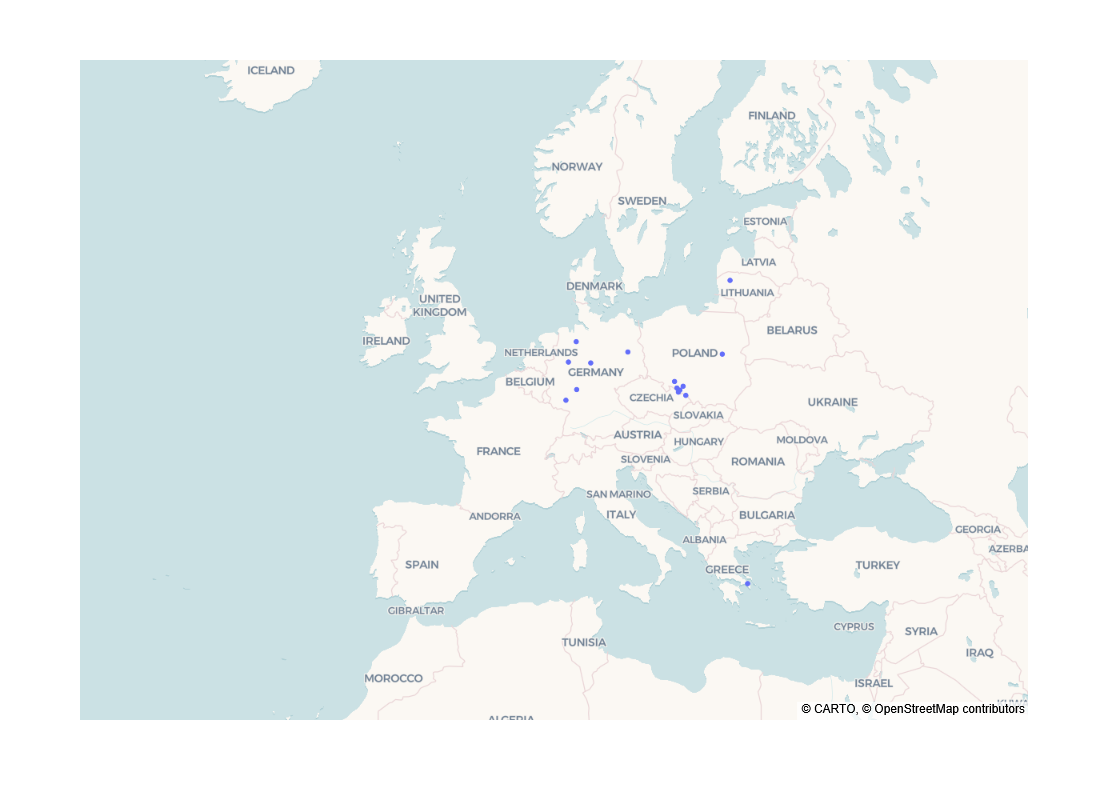

In [74]:
fig = px.scatter_map(city_df_detail[city_df_detail['cluster'] == 79], lat="lat", lon="lng", hover_name = 'name', zoom = 3)
fig.update_layout(height=800)
fig.show()

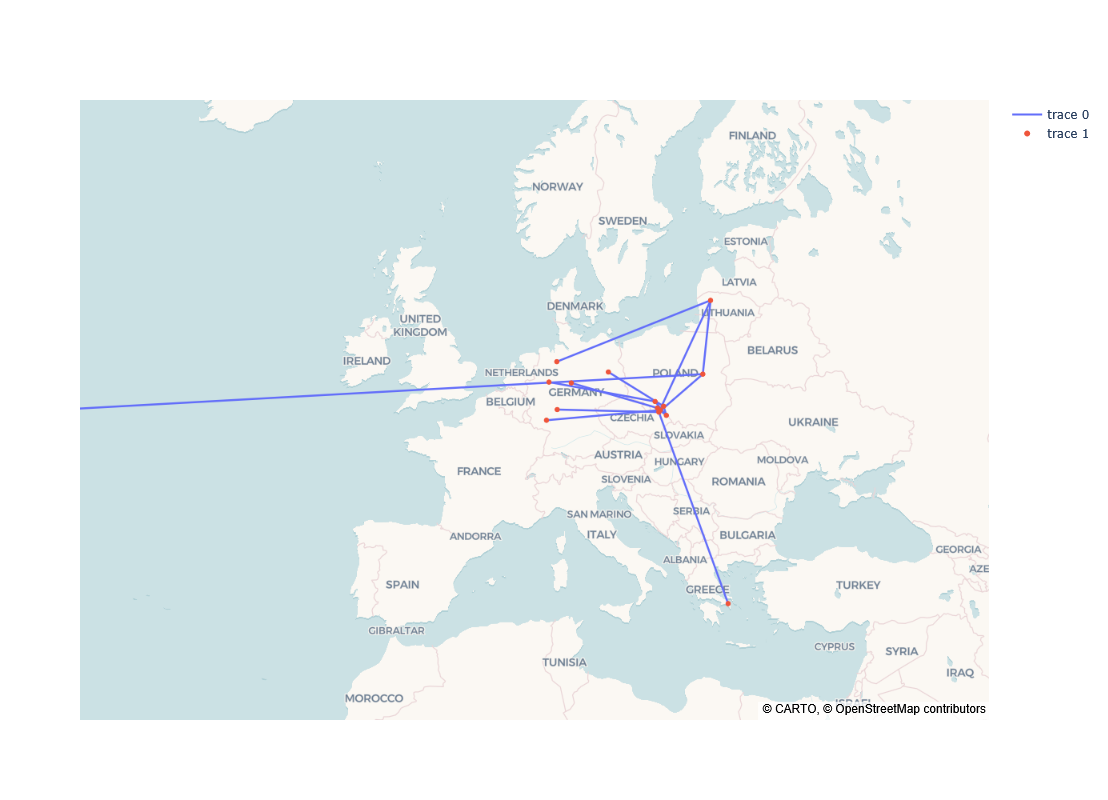

In [97]:
cluster_num = 79

fig2 = go.Figure()

# lat_list = [[rows['lat_source'],rows['lat_target'], None] for index, rows in city_df_viz[city_df_viz['cluster_source']==cluster_num].iterrows()]
lat_list = [x for index, rows in city_df_viz[city_df_viz['cluster_source']==cluster_num].iterrows() for x in [rows['lat_source'], rows['lat_target'], None]]
# long_list =[[rows['lng_source'],rows['lng_target'], None] for index, rows in city_df_viz[city_df_viz['cluster_source']==cluster_num].iterrows()]
long_list = [x for index, rows in city_df_viz[city_df_viz['cluster_source']==cluster_num].iterrows() for x in [rows['lng_source'], rows['lng_target'], None]]

city_df_detail_filtered = city_df_detail[city_df_detail['cluster'] == cluster_num]

fig2.add_trace(go.Scattermap(mode = 'lines',
                             lat = lat_list,
                             lon = long_list))

fig2.add_trace(go.Scattermap(mode = 'markers',
                             lat = city_df_detail_filtered['lat'],
                             lon = city_df_detail_filtered['lng'],
                             text = city_df_detail_filtered['name']))
fig2.update_layout(height=800,
                  map = {'zoom':3,
                        'center': {'lon':np.average(city_df_detail_filtered['lng']),
                                   'lat':np.average(city_df_detail_filtered['lat'])}
                        })

# fig2.write_image('Documents/TidyTuesday260512/map_cluster1.png')
